In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy

# Q1

### Generate a normally distributed dataset using numpy.random.normal().
Plot a histogram and KDE using seaborn.histplot or sns.kdeplot.

Overlay the mean and standard deviation lines on the plot.

Use scipy.stats.norm.pdf to show the bell curve (optional).

In [3]:
dataset = np.random.normal(100000,20000,1000)
mean = np.mean(dataset)
std = np.std(dataset)

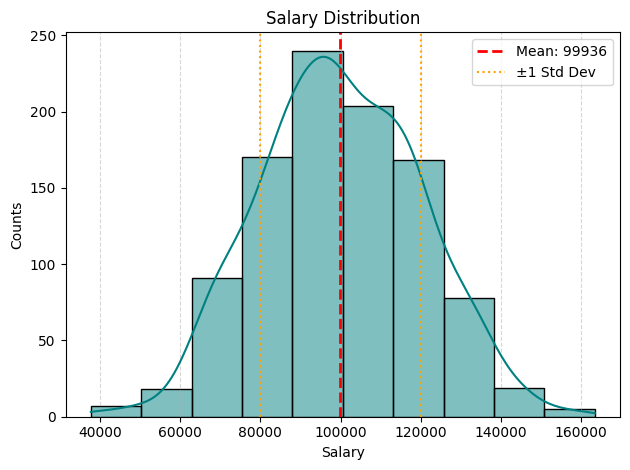

In [4]:
sns.histplot(data=dataset,bins=10,kde=True,color="teal",edgecolor="black")
plt.axvline(mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean:.0f}')
plt.axvline(mean + std, color='orange', linestyle=':', linewidth=1.5, label='±1 Std Dev')
plt.axvline(mean - std, color='orange', linestyle=':', linewidth=1.5)
plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Counts")
plt.tight_layout()
plt.legend()
plt.grid(axis="x",linestyle="--",alpha=0.5)
plt.show()

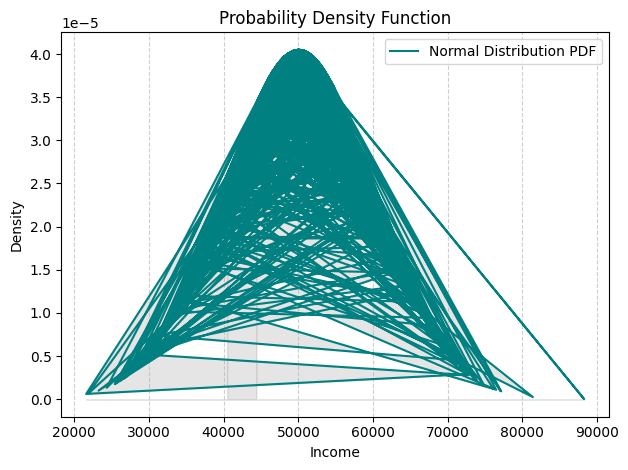

In [5]:
x = np.random.normal(50000,10000,1000)
mean = np.mean(x)
standard_devaition = np.std(x)

y = scipy.stats.norm.pdf(x,loc=mean,scale=standard_devaition)

plt.plot(x,y,label="Normal Distribution PDF",color="teal")
plt.fill_between(x, y, alpha=0.10, color='black')
plt.title("Probability Density Function")
plt.xlabel("Income")
plt.ylabel("Density")
plt.tight_layout()
plt.grid(axis="x",linestyle="--",alpha=0.6)
plt.legend()
plt.show()

C:\Users\namya\AppData\Local\Temp\ipykernel_16196\2516628110.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


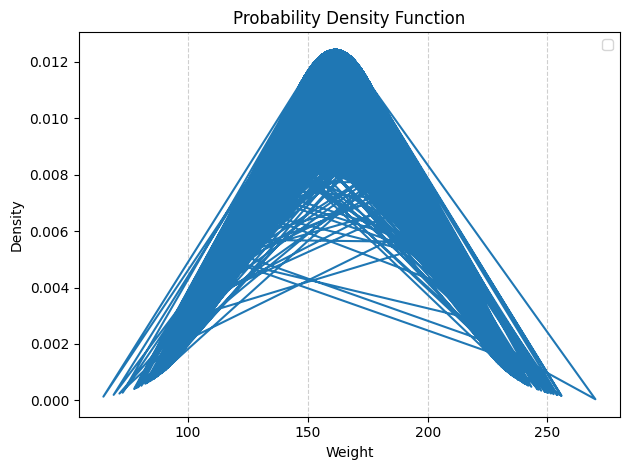

In [6]:

measurement_data = pd.read_csv("weight-height.csv")
mean = np.mean(measurement_data["Weight"])
std = np.std(measurement_data["Weight"])

y = scipy.stats.norm.pdf(measurement_data["Weight"],loc=mean,scale=std)

plt.plot(measurement_data["Weight"],y)
plt.title("Probability Density Function")
plt.xlabel("Weight")
plt.ylabel("Density")
plt.tight_layout()
plt.grid(axis="x",linestyle="--",alpha=0.6)
plt.legend()
plt.show()

# Q2

### Load a sample dataset and select a numeric column.

Calculate using numpy.percentile() or df.quantile():

25th percentile

50th percentile (median)

75th percentile

### Plot these quartiles using vertical lines on a boxplot or histogram.

In [7]:
car_prices = pd.read_csv("car_prices.csv")
car_prices

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
558832,2015,Kia,K900,Luxury,Sedan,NaN,knalw4d4xf6019304,in,45.0,18255.0,silver,black,avis corporation,35300.0,33000.0,Thu Jul 09 2015 07:00:00 GMT-0700 (PDT)
558833,2012,Ram,2500,Power Wagon,Crew Cab,automatic,3c6td5et6cg112407,wa,5.0,54393.0,white,black,i -5 uhlmann rv,30200.0,30800.0,Wed Jul 08 2015 09:30:00 GMT-0700 (PDT)
558834,2012,BMW,X5,xDrive35d,SUV,automatic,5uxzw0c58cl668465,ca,48.0,50561.0,black,black,financial services remarketing (lease),29800.0,34000.0,Wed Jul 08 2015 09:30:00 GMT-0700 (PDT)
558835,2015,Nissan,Altima,2.5 S,sedan,automatic,1n4al3ap0fc216050,ga,38.0,16658.0,white,black,enterprise vehicle exchange / tra / rental / t...,15100.0,11100.0,Thu Jul 09 2015 06:45:00 GMT-0700 (PDT)


In [8]:
car_prices["condition"].isnull().sum()
clean_condition = car_prices["condition"].dropna()
percentile_25 = np.percentile(clean_condition, 25)
percentile_50 = np.percentile(clean_condition,50)
percentile_75 = np.percentile(clean_condition,75)
print(percentile_25)
print(percentile_50)
print(percentile_75)


23.0
35.0
42.0


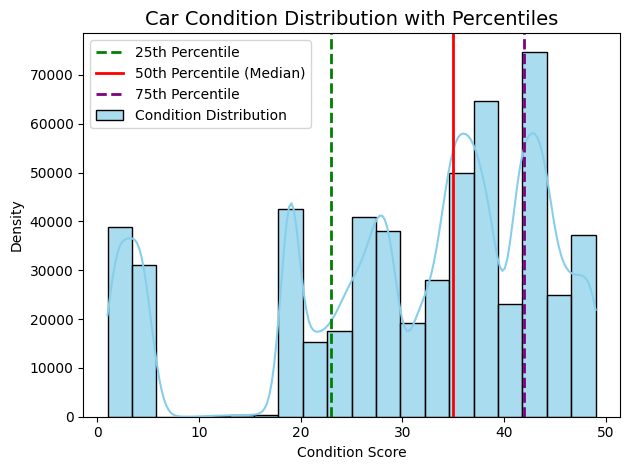

In [9]:
sns.histplot(car_prices["condition"], kde=True, bins=20, color="skyblue", edgecolor="black", alpha=0.7, label="Condition Distribution")
plt.axvline(percentile_25, color="green", linestyle="--", linewidth=2, label="25th Percentile")
plt.axvline(percentile_50, color="red", linestyle="-", linewidth=2, label="50th Percentile (Median)")
plt.axvline(percentile_75, color="purple", linestyle="--", linewidth=2, label="75th Percentile")
plt.title("Car Condition Distribution with Percentiles", fontsize=14)
plt.xlabel("Condition Score")
plt.ylabel("Density")
plt.tight_layout()
plt.legend()
plt.show()

# Q3

### Print the five-number summary (min, Q1, median, Q3, max) of a column.

### Create a boxplot using seaborn.boxplot() or matplotlib.

### Identify and label outliers from the boxplot.

In [10]:
car_prices["sellingprice"].isnull().sum()
clean_sellingprice = car_prices["sellingprice"].dropna()

In [11]:
sellingprice_min = np.min(clean_sellingprice)
sellingprice_25 = np.percentile(clean_sellingprice,25)
sellingprice_50 = np.median(clean_sellingprice)
sellingprice_75 = np.percentile(clean_sellingprice,75)
sellingprice_max = np.max(clean_sellingprice)
print(f"Minimum : {sellingprice_min}")
print(f"Q1 : {sellingprice_25}")
print(f"Median : {sellingprice_50}")
print(f"Q3 : {sellingprice_75}")
print(f"Maximum : {sellingprice_max}")

Minimum : 1.0
Q1 : 6900.0
Median : 12100.0
Q3 : 18200.0
Maximum : 230000.0


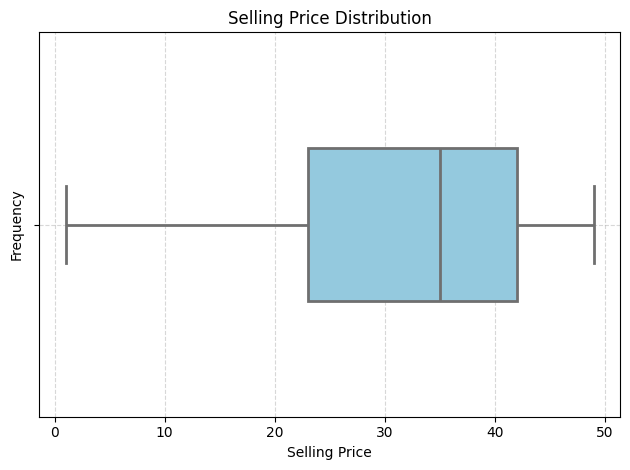

In [23]:
sns.boxplot(data=clean_condition,orient="h",color="skyblue",width=0.4,fliersize=6,flierprops=dict(marker='o', color='red', alpha=0.6),linewidth=2)
# plt.axvline(sellingprice_50, color="red", linestyle="--", label=f"Median: {sellingprice_50:.2f}")

# plt.axvline(sellingprice_25, color="green", linestyle="--", label=f"Quarter 1: {sellingprice_25:.2f}")

# plt.axvline(sellingprice_75, color="purple", linestyle="--", label=f"Quarter 3: {sellingprice_75:.2f}")


plt.title("Selling Price Distribution")
plt.xlabel("Selling Price")
plt.ylabel("Frequency")
plt.tight_layout()
plt.grid(axis="both",linestyle="--",alpha=0.5)
plt.show()

# Q5

### In a markdown cell, define inferential statistics and list real-world use cases

(e.g., polling, clinical trials, A/B testing).
### Load a sample population dataset. Take a random sample using df sample and compare the sample mean to the population mean.

Repeat sampling multiple times and visualize the sample mean distribution.

### Inferential statistics is about:

Making predictions, conclusions, or decisions about a large population based on data from a small sample.

It’s like reading the entire book by analyzing a few pages.

### Healthcare & Medicine
### Business & Marketing
### Government & Policy
### Manufacturing & Quality Control
### Sports Analytics

In [36]:
population_dataset = pd.read_csv("world_population.csv")
df = pd.DataFrame(population_dataset)

sample_dataset1 = df.sample(n=50)
population_mean1 = np.mean(population_dataset["2022 Population"])
sample_mean1 = np.mean(sample_dataset1["2022 Population"])

sample_dataset2 = df.sample(n=20)
population_mean2 = np.mean(population_dataset["2022 Population"])
sample_mean2 = np.mean(sample_dataset2["2022 Population"])

sample_dataset3 = df.sample(n=90)
population_mean3 = np.mean(population_dataset["2022 Population"])
sample_mean3 = np.mean(sample_dataset3["2022 Population"])

### Sample And Population Mean(1)

In [34]:
print(f"Population Mean1 : {population_mean1}")
print(f"Sample Mean1 : {sample_mean1}")

Population Mean1 : 34074414.70940171
Sample Mean1 : 50271309.26


### Sample And Population Mean(2)

In [35]:
print(f"Population Mean2 : {population_mean2}")
print(f"Sample Mean2 : {sample_mean2}")

Population Mean2 : 34074414.70940171
Sample Mean2 : 84213577.4


### Sample And Population Mean(3)

In [37]:
print(f"Population Mean3 : {population_mean3}")
print(f"Sample Mean3 : {sample_mean3}")

Population Mean3 : 34074414.70940171
Sample Mean3 : 35407697.35555556
